**TITLE**

**Deep** **Learning–Based Food Wrapper Image Classification Using CNN**

**PROBLEM STATEMENT**

With the rapid growth of digital images in e-commerce, retail, and inventory management systems, manual classification of food products is time-consuming, error-prone, and inefficient. There is a need for an automated image-based classification system that can accurately identify food product categories from images, even when variations in lighting, background, and packaging exist. This project aims to address this problem by developing a CNN-based image classification model.

**DOMAIN**

The project falls under the Retail and E-commerce domain, with applications in inventory management, automated product categorization, and smart retail systems. It also intersects with the broader domain of Computer Vision and Artificial Intelligence.

**OBJECTIVES**

The primary objective of this project is to design and implement an image classification system capable of categorizing food items using CNN models. Additional objectives include preprocessing raw image data, training a normal CNN and a pretrained CNN model, evaluating model performance using accuracy and confusion matrices, and comparing the effectiveness of transfer learning against a CNN trained from scratch.

**DATASET SOURCES**

 dataset used for the FoodWrapper project consists of approximately 2000 real-world food wrapper images collected manually using mobile devices. Images were captured in real retail environments such as grocery stores, featuring packaged food products including biscuits, chips, chocolates, and juices. In addition to static images, short video clips were recorded and converted into image frames to increase dataset size and diversity. The collected data reflects real-world conditions with variations in lighting, background clutter, camera angles, and shelf arrangements. To further balance the dataset and improve model generalization, data augmentation techniques were applied. The final dataset was organized into training, validation, and test sets for effective model evaluation.

**METHODOLOGY**

The proposed methodology begins with data collection through images and video frame extraction, followed by preprocessing steps such as resizing, normalization, and augmentation. The dataset is then split into training, validation, and test sets. CNN-based models are trained on the processed data, including a normal CNN trained from scratch and a pretrained CNN using transfer learning. Model performance is evaluated using accuracy, loss curves, and confusion matrix analysis, followed by result comparison and interpretation.

**TOOLS & TECHNOLOGIES**

The project is implemented using Python as the core programming language. Libraries such as TensorFlow and Keras are used for building and training CNN models, NumPy and Pandas for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for evaluation metrics. Development and experimentation are carried out using Google Colab.

Upload ZIP FILE DIRECLTY INTO COLAB

In [ ]:
from google.colab import files
uploaded = files.upload()   # click Choose Files and select final_dataset.zip


Saving final_dataset.zip to final_dataset.zip


UNZIP INSIDE COLAB

In [ ]:
!unzip -o -q final_dataset.zip -d /content/final_dataset
!ls -R /content/final_dataset



/content/final_dataset:
final_dataset

/content/final_dataset/final_dataset:
test  train  val

/content/final_dataset/final_dataset/test:
biscuits  chips  chocolate  juices

/content/final_dataset/final_dataset/test/biscuits:
 frame_00002.jpg   frame_00228.jpg
 frame_00011.jpg   frame_00257.jpg
 frame_00012.jpg   frame_00278.jpg
 frame_00014.jpg   frame_00286.jpg
 frame_00015.jpg   frame_00300.jpg
 frame_00043.jpg   frame_00301.jpg
 frame_00046.jpg   frame_00307.jpg
 frame_00051.jpg  'WhatsApp Image 2025-12-10 at 11.48.51 PM (2).jpeg'
 frame_00056.jpg  'WhatsApp Image 2025-12-10 at 11.48.59 PM.jpeg'
 frame_00070.jpg  'WhatsApp Image 2025-12-10 at 11.50.09 PM.jpeg'
 frame_00078.jpg  'WhatsApp Image 2025-12-10 at 11.51.08 PM.jpeg'
 frame_00080.jpg  'WhatsApp Image 2025-12-10 at 11.51.09 PM.jpeg'
 frame_00100.jpg  'WhatsApp Image 2025-12-10 at 11.51.13 PM.jpeg'
 frame_00109.jpg  'WhatsApp Image 2025-12-10 at 11.51.24 PM.jpeg'
 frame_00110.jpg  'WhatsApp Image 2025-12-10 at 11.51.26 PM.jpe

In [ ]:
# run this to confirm files & counts
import os
from pathlib import Path

data_root = Path("/content/final_dataset/final_dataset")
for split in ("train","val","test"):
    print(f"\n== {split} ==")
    split_dir = data_root / split
    if not split_dir.exists():
        print("  MISSING:", split_dir)
        continue
    total_split = 0
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = split_dir / cls
        if cls_dir.is_dir():
            n = len([f for f in cls_dir.iterdir() if f.is_file()])
            print(f"  {cls}: {n}")
            total_split += n
    print("  TOTAL in", split, "=", total_split)

print("\nDATA ROOT:", data_root)



== train ==
  biscuits: 371
  chips: 373
  chocolate: 376
  juices: 378
  TOTAL in train = 1498

== val ==
  biscuits: 74
  chips: 75
  chocolate: 75
  juices: 76
  TOTAL in val = 300

== test ==
  biscuits: 50
  chips: 50
  chocolate: 51
  juices: 51
  TOTAL in test = 202

DATA ROOT: /content/final_dataset/final_dataset


NORMAL CNN WITHOUT PRETRAINED MODEL

Classes: ['biscuits', 'chips', 'chocolate', 'juices']
TEST IMAGE FROM DATASET
Actual Class: chips
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


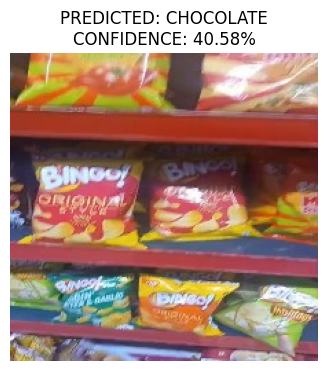

Image Path: /content/final_dataset/final_dataset/test/chips/frame_00080.jpg
Predicted Class: chocolate
Confidence: 40.58 %
----------------------------------------


In [ ]:
# =========================================================
# NORMAL CNN – DISPLAY TEST IMAGE WITH PREDICTION & ACCURACY
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# -------- CONFIG --------
DATA_ROOT = Path("/content/final_dataset/final_dataset")
IMG_SIZE = (224,224)
# ------------------------

# -------- CLASS NAMES --------
class_names = sorted([
    d.name for d in (DATA_ROOT / "train").iterdir()
    if d.is_dir()
])

print("Classes:", class_names)

# -------- FUNCTION TO DISPLAY PREDICTION --------
def display_prediction(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    preds = model.predict(img_arr)[0]
    idx = np.argmax(preds)
    pred_class = class_names[idx]
    confidence = preds[idx] * 100

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"PREDICTED: {pred_class.upper()}\n"
        f"CONFIDENCE: {confidence:.2f}%"
    )
    plt.show()

    print("Image Path:", image_path)
    print("Predicted Class:", pred_class)
    print("Confidence:", round(confidence,2), "%")
    print("-"*40)

# -------- PICK & DISPLAY RANDOM TEST IMAGE --------
test_root = DATA_ROOT / "test"
actual_class = random.choice([d for d in test_root.iterdir() if d.is_dir()])
test_image = random.choice(list(actual_class.glob("*")))

print("TEST IMAGE FROM DATASET")
print("Actual Class:", actual_class.name)
display_prediction(test_image)


MODEL TRAINING(PRETRAINED MODEL EFFICIENT NET 50)

In [ ]:
# STEP 1: Model Training (EfficientNetB0)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input, EfficientNetB0
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from pathlib import Path

DATA_ROOT = Path("/content/final_dataset/final_dataset")
IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Data generators
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_flow = train_gen.flow_from_directory(
    DATA_ROOT/"train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_flow = val_gen.flow_from_directory(
    DATA_ROOT/"val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Build model
base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(train_flow.num_classes, activation="softmax")(x)

model = Model(base.input, output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history1 = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=12,
    callbacks=[
        ReduceLROnPlateau(patience=3),
        EarlyStopping(patience=6, restore_best_weights=True)
    ]
)


Found 1498 images belonging to 4 classes.
Found 300 images belonging to 4 classes.
Epoch 1/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 64s 960ms/step - accuracy: 0.6776 - loss: 0.7826 - val_accuracy: 0.9367 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 2/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9362 - loss: 0.1982 - val_accuracy: 0.9533 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 3/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 444ms/step - accuracy: 0.9407 - loss: 0.1627 - val_accuracy: 0.9600 - val_loss: 0.1290 - learning_rate: 0.0010
Epoch 4/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9723 - loss: 0.0885 - val_accuracy: 0.9700 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 5/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 465ms/step - accuracy: 0.9851 - loss: 0.0670 - val_accuracy: 0.9633 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 6/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.9745 - loss: 0.0739 - val_accuracy: 0.9767 - val_loss: 0.0786 - learning_rate: 0.0010

FINE-TUNING

In [ ]:
# STEP 2: Fine-tuning last layers

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10
)


Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7919 - loss: 0.5485 - val_accuracy: 0.9700 - val_loss: 0.0833
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 446ms/step - accuracy: 0.8430 - loss: 0.4167 - val_accuracy: 0.9667 - val_loss: 0.1001
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.8985 - loss: 0.3051 - val_accuracy: 0.9633 - val_loss: 0.1122
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.9353 - loss: 0.2191 - val_accuracy: 0.9633 - val_loss: 0.1194
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 437ms/step - accuracy: 0.9318 - loss: 0.2238 - val_accuracy: 0.9633 - val_loss: 0.1224
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 436ms/step - accuracy: 0.9490 - loss: 0.1861 - val_accuracy: 0.9667 - val_loss: 0.1220
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.9542 - loss: 0.1811 - val_accuracy: 0.9733 - val_loss: 0.1205
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 455ms/step - accuracy: 0.9625 - loss: 0.1597 - val_accurac

TEST SET ACCURACY

In [ ]:
# STEP 3: Test Accuracy

test_flow = val_gen.flow_from_directory(
    DATA_ROOT/"test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

loss, acc = model.evaluate(test_flow)
print("TEST LOSS:", round(loss,4))
print("TEST ACCURACY:", round(acc*100,2), "%")


Found 202 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9350 - loss: 0.2086
TEST LOSS: 0.1462
TEST ACCURACY: 96.04 %


OVER ALL ACCURACY AND LOSS GRAPH

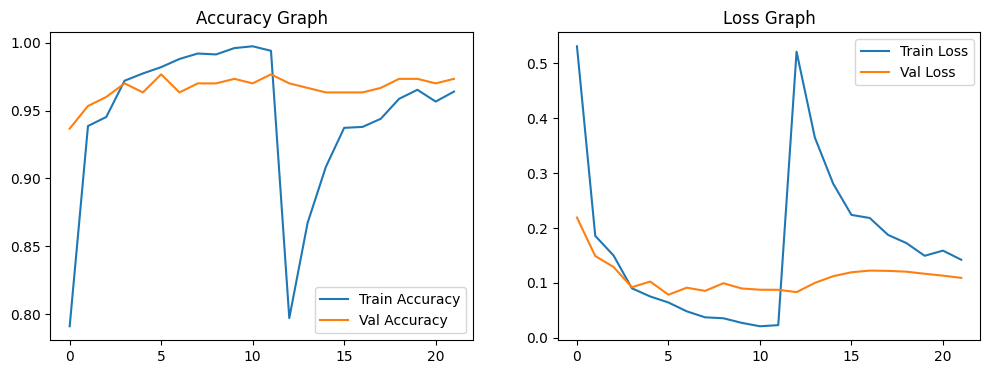

In [ ]:
# STEP 4: Accuracy & Loss Graph

import matplotlib.pyplot as plt

train_acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
train_loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(len(train_acc))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Graph")

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.legend()
plt.title("Loss Graph")

plt.show()


CONFUSION MATRIX

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


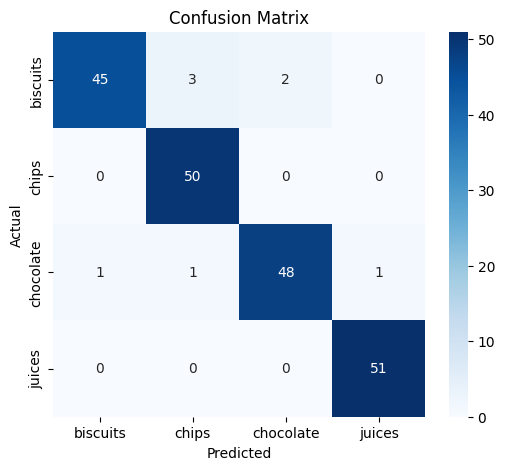

Classification Report:

              precision    recall  f1-score   support

    biscuits       0.98      0.90      0.94        50
       chips       0.93      1.00      0.96        50
   chocolate       0.96      0.94      0.95        51
      juices       0.98      1.00      0.99        51

    accuracy                           0.96       202
   macro avg       0.96      0.96      0.96       202
weighted avg       0.96      0.96      0.96       202



In [ ]:
# STEP 5: Confusion Matrix

import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(test_flow), axis=1)
y_true = test_flow.classes
labels = list(test_flow.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))


TEST IMAGE DISPLAY (ACTUAL vs PREDICTED)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


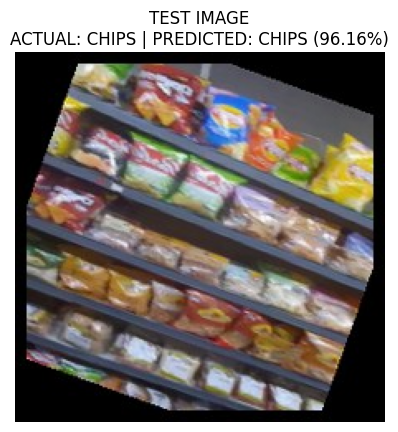

In [ ]:
# STEP 6: Display Test Image with Prediction

import random, numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

class_names = labels

test_root = DATA_ROOT/"test"
actual_class = random.choice([d for d in test_root.iterdir() if d.is_dir()])
img_path = random.choice(list(actual_class.glob("*")))

img = load_img(img_path, target_size=(224,224))
img_arr = img_to_array(img)
img_arr = preprocess_input(img_arr)
img_arr = np.expand_dims(img_arr, 0)

pred = model.predict(img_arr)[0]
pred_class = class_names[np.argmax(pred)]
confidence = max(pred)*100

plt.imshow(img)
plt.axis("off")
plt.title(
    f"TEST IMAGE\nACTUAL: {actual_class.name.upper()} | "
    f"PREDICTED: {pred_class.upper()} ({confidence:.2f}%)"
)
plt.show()


USER INPUT UPLOAD

In [ ]:
# STEP 7: User Image Upload

from google.colab import files
uploaded = files.upload()


Saving USER INPUT CCOCO 3.jpg to USER INPUT CCOCO 3.jpg
Saving USER INPUT CHCOC 2.jpg to USER INPUT CHCOC 2.jpg
Saving USER_INPUT CHOCO.jpg to USER_INPUT CHOCO.jpg


USER INPUT PREDICTION

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


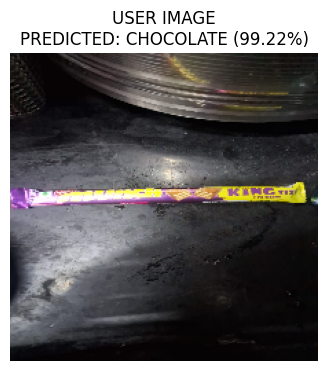

Image: USER INPUT CCOCO 3.jpg
Predicted Class: chocolate
Confidence: 99.22 %
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


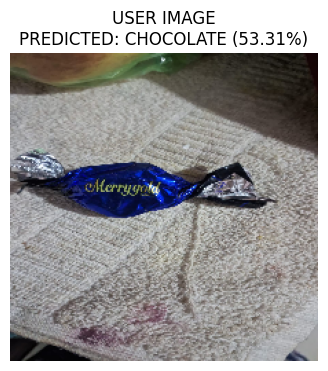

Image: USER INPUT CHCOC 2.jpg
Predicted Class: chocolate
Confidence: 53.31 %
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


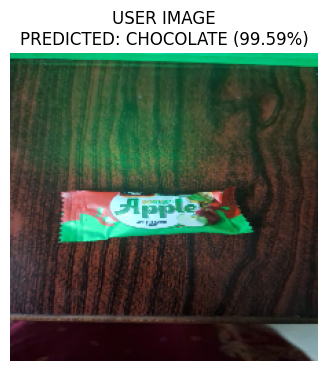

Image: USER_INPUT CHOCO.jpg
Predicted Class: chocolate
Confidence: 99.59 %
----------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

for img_path in uploaded.keys():
    # Load & preprocess
    img = load_img(img_path, target_size=(224,224))
    img_arr = img_to_array(img)
    img_arr = preprocess_input(img_arr)
    img_arr = np.expand_dims(img_arr, axis=0)

    # Predict
    preds = model.predict(img_arr)[0]
    idx = np.argmax(preds)
    pred_class = class_names[idx]
    confidence = preds[idx] * 100

    # Display
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"USER IMAGE\nPREDICTED: {pred_class.upper()} ({confidence:.2f}%)")
    plt.show()

    print("Image:", img_path)
    print("Predicted Class:", pred_class)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 40)


**CONCLUSION**

In this project, an automated food wrapper classification system named FoodWrapper was successfully developed using convolutional neural networks. Initially, a normal CNN trained from scratch was implemented using the collected real-world dataset; however, the achieved accuracy was comparatively lower due to limited data and complex backgrounds present in retail images. To overcome these limitations, a pretrained CNN model using EfficientNet with transfer learning was employed, which significantly improved feature extraction and generalization capability. The pretrained model achieved a high overall accuracy of approximately 96% on the test dataset, demonstrating its effectiveness compared to the normal CNN approach. The project highlights the importance of transfer learning for real-world image classification tasks and confirms that pretrained models perform better when training data is limited. Additionally, performance evaluation using accuracy graphs, confusion matrices, and visual prediction outputs validated the reliability of the proposed system. Overall, the FoodWrapper system provides an efficient and scalable solution for automated food product classification in retail and e-commerce environments.